## General ##
This Jupyter notebook is for us to write code all at the same time. Please only write code in your given cells, indicated with the markdown.

## Writing code ##
We keep the unknown values for work on the weekends 
Compare per months for other categories, where you do have the data
Filters dataset: 2019 and 2023
(second dataset) Graph with colors of what cities are “stedelijk” and “niet stedelijk” → map of the Netherlands what is “stedelijk” and “niet stedelijk”
Dataset is in Dutch, but when plotting we can translate the axis’

Things to look at:
- Per year
- Urban vs rural
- Differences between school levels
- Whether week or weekend public transport (OV) or person cars matters

## Fleur ##

In [115]:
'''Importing needed libraries'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [116]:
df_og = pd.read_csv('Dataset2_all.csv', 
                    delimiter= ';',
                    header= [1, 2, 3, 4, 5],
                    skiprows= 4, # skip the first 4 rows because they don't contain any needed data
                    encoding='utf-8-sig'
                    ) 

df2 = df_og.copy()          # make a copy

df2.columns = ['_'.join([str(c) for c in col if str(c) != 'nan']).strip('_') for col in df2.columns] # makes one row of the index 

df2.head(12)

,Persoonskenmerken_Onderwerp_Regio's_Perioden_Reismotieven,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Weinig stedelijk_2019_aantal,...,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2023_reizigerskilometers
0,Totaal,"2,79","2,68","2,65","2,51","2,76","2,71","2,89","2,74","2,95",...,"23,95","20,01","23,94","23,49","24,72","23,99","29,39","26,65","30,81","31,16"
1,Van en naar het werk,"0,15","0,14","0,15","0,12","0,14","0,14","0,13","0,13","0,18",...,"1,43","0,81","1,60","1,36","1,20","0,81","1,49","1,32",.,.
2,"Winkelen, boodschappen doen","0,29","0,32","0,35","0,39","0,28","0,32","0,29","0,30","0,24",...,"1,28","1,51","1,17","1,56","2,35","1,80","2,02","2,44","2,91",.
3,"Onderwijs volgen, cursus, kinderopvang","0,98","0,85","0,91","0,75","0,97","0,90","1,06","0,90","1,05",...,"6,23","4,34","6,93","6,49","8,06","6,65","8,69","7,40","9,84","8,74"
4,"Visite, logeren","0,29","0,29","0,25","0,24","0,31","0,29","0,29","0,30","0,32",...,"5,30","4,49","4,83","4,26","3,97","4,47","4,47","4,03","3,72","4,70"
5,"Uitgaan, sport, hobby","0,78","0,74","0,70","0,68","0,77","0,73","0,80","0,78","0,89",...,"6,36","5,77","6,26","7,16","6,06","7,09","9,63","8,61","7,99","10,00"
6,Bron: CBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
'''Filtering for missing or non-valid values
nothing : this number just doesn't exists based on logical facts
. : number is unknown, not reliable or secret
* : provisional number
** : additional provisional numberws if applicable'''

print("Empty cels:", df2.isna().sum().sum())            # count empty cells 
print("Cels with '.':", (df2 == '.').sum().sum())       # count . 
print("Cels with '*':", (df2 == '*').sum().sum())       # count *
print("Cels with '**':", (df2 == '**').sum().sum())     # count **
df2 = df2.replace({'.': 0, '*': np.nan, '**': np.nan})  # replacing all the '.' as a NaN
print("Empty cels:", df2.isna().sum().sum())            # check is replacing is done

'''Changing numeric colums to real values'''

df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore')) # replaces strings to numbers 

df2.head(12)                                              # shows the new table 




Empty cels: 0
Cels with '.': 0
Cels with '*': 0
Cels with '**': 0
Empty cels: 0


C:\Users\fleur\AppData\Local\Temp\ipykernel_27116\660409564.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore')) # replaces strings to numbers
C:\Users\fleur\AppData\Local\Temp\ipykernel_27116\660409564.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore')) # replaces strings to numbers


,Persoonskenmerken_Onderwerp_Regio's_Perioden_Reismotieven,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Weinig stedelijk_2019_aantal,...,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2023_reizigerskilometers
0,Totaal,2.79,2.68,2.65,2.51,2.76,2.71,2.89,2.74,2.95,...,23.95,20.01,23.94,23.49,24.72,23.99,29.39,26.65,30.81,31.16
1,Van en naar het werk,0.15,0.14,0.15,0.12,0.14,0.14,0.13,0.13,0.18,...,1.43,0.81,1.6,1.36,1.2,0.81,1.49,1.32,0,0
2,Winkelen. boodschappen doen,0.29,0.32,0.35,0.39,0.28,0.32,0.29,0.3,0.24,...,1.28,1.51,1.17,1.56,2.35,1.8,2.02,2.44,2.91,0
3,Onderwijs volgen. cursus. kinderopvang,0.98,0.85,0.91,0.75,0.97,0.9,1.06,0.9,1.05,...,6.23,4.34,6.93,6.49,8.06,6.65,8.69,7.4,9.84,8.74
4,Visite. logeren,0.29,0.29,0.25,0.24,0.31,0.29,0.29,0.3,0.32,...,5.3,4.49,4.83,4.26,3.97,4.47,4.47,4.03,3.72,4.7
5,Uitgaan. sport. hobby,0.78,0.74,0.7,0.68,0.77,0.73,0.8,0.78,0.89,...,6.36,5.77,6.26,7.16,6.06,7.09,9.63,8.61,7.99,10.0
6,Bron: CBS,nan,nan,nan,nan,nan,nan,nan,nan,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


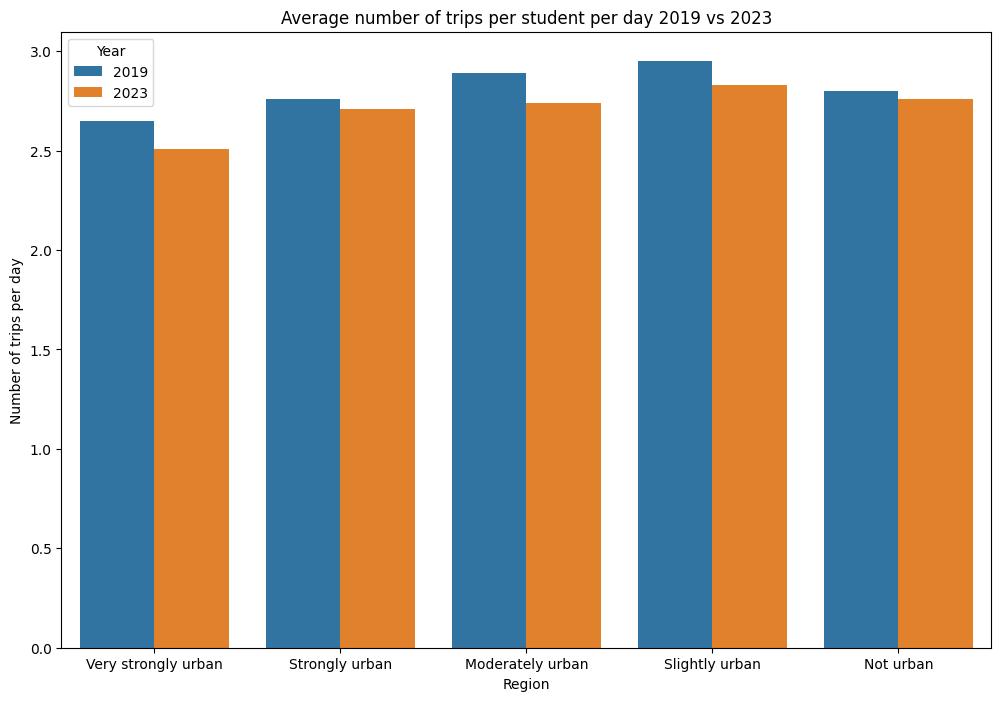

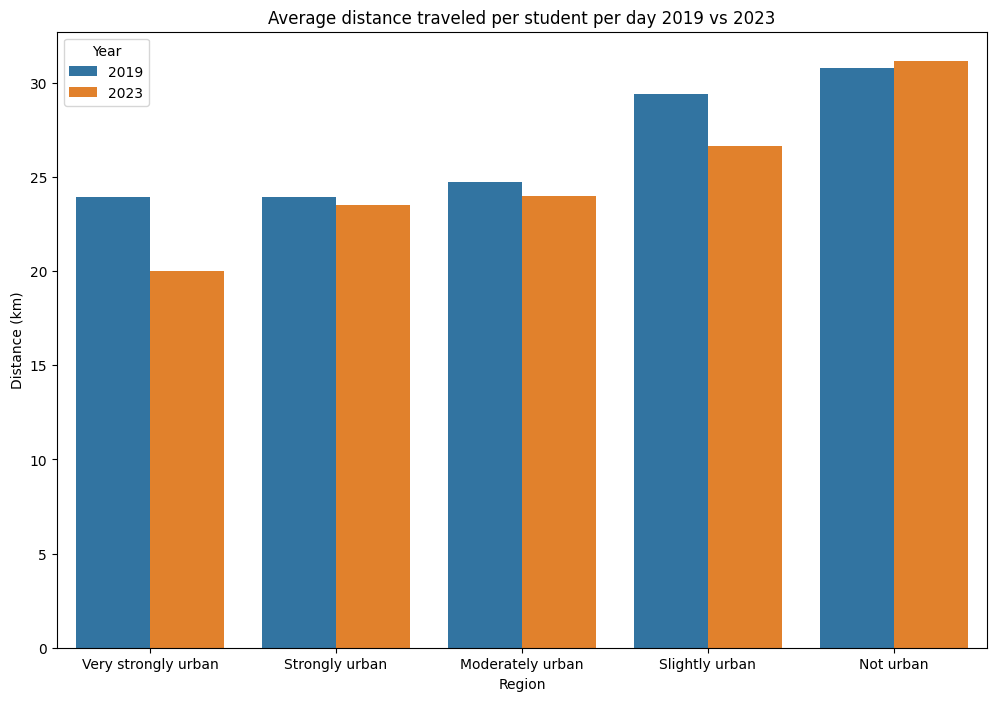

In [120]:
# Filter the 'Totaal' row
df_totaal = df2[df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'] == 'Totaal']

# Regions and years
regio_list = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']
jaar_list = ['2019', '2023']

# Function to find column names that match by subject, region and year
def get_columns(df, onderwerp, jaren):
    cols = []
    regio_mapping = {
        'Very strongly urban': 'Zeer sterk stedelijk',
        'Strongly urban': 'Sterk stedelijk',
        'Moderately urban': 'Matig stedelijk',
        'Slightly urban': 'Weinig stedelijk',
        'Not urban': 'Niet stedelijk'
    }
    for regio_eng in regio_list:
        regio_nl = regio_mapping[regio_eng]
        for jaar in jaren:
            match = [c for c in df.columns if onderwerp in c and regio_nl in c and jaar in c]
            if match:
                cols.append(match[0])
    return cols

# Automatically select columns
cols_aantal = get_columns(df_totaal, 'Verplaatsingen', jaar_list)
cols_km = get_columns(df_totaal, 'Afstand', jaar_list)

# Create a long-form data frame for plotting
data_plot = pd.DataFrame({
    'Regio': [regio for regio in regio_list for _ in jaar_list],
    'Jaar': jaar_list*len(regio_list),
    'Aantal verplaatsingen': df_totaal[cols_aantal].values.flatten(),
    'Afstand (km)': df_totaal[cols_km].values.flatten()
})

# Plot number of movements
plt.figure(figsize=(12,8))
sns.barplot(x='Regio', y='Aantal verplaatsingen', hue='Jaar', data=data_plot)
plt.title('Average number of trips per student per day 2019 vs 2023')
plt.ylabel('Number of trips per day')
plt.xlabel('Region')
plt.legend(title='Year')
plt.show()

# Plot distance 
plt.figure(figsize=(12,8))
sns.barplot(x='Regio', y='Afstand (km)', hue='Jaar', data=data_plot)
plt.title('Average distance traveled per student per day 2019 vs 2023')
plt.ylabel('Distance (km)')
plt.xlabel('Region')
plt.legend(title='Year')
plt.show()

TypeError: can only concatenate str (not "numpy.float64") to str

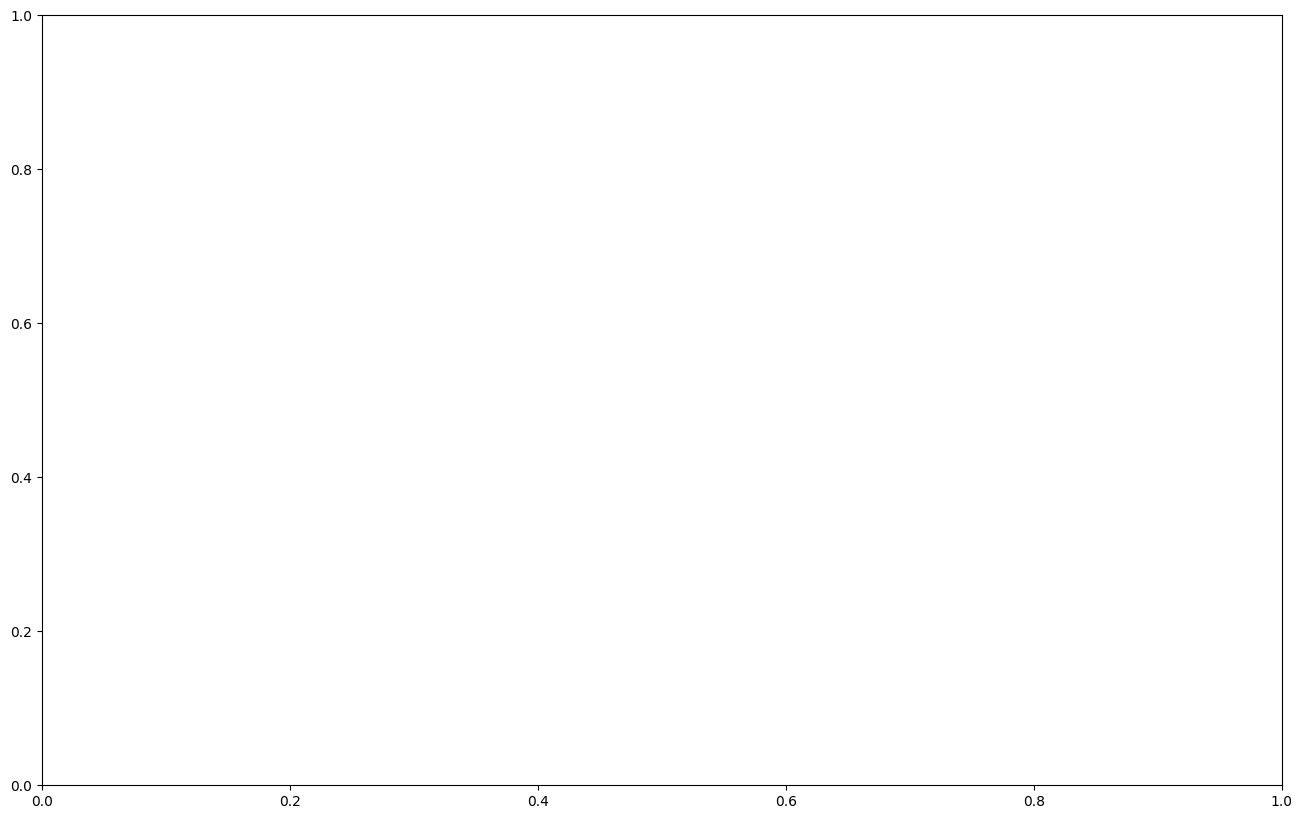

In [122]:
# Travel motives
motieven_eng = {
    'Van en naar het werk': 'Work',
    'Winkelen. boodschappen doen': 'Shopping',
    'Onderwijs volgen. cursus. kinderopvang': 'Education / Childcare',
    'Visite. logeren': 'Visiting / Overnight stay',
    'Uitgaan. sport. hobby': 'Leisure / Sport / Hobby',
    'Overig': 'Other'
}

# Regions and years
regio_list = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']
jaar_list = ['2019', '2023']

def plot_absolute_stacked_english(df_plot, titel, ylabel):
    # Fixed order of motives
    fixed_order = ['Onderwijs volgen. cursus. kinderopvang',
                   'Uitgaan. sport. hobby',
                   'Winkelen. boodschappen doen',
                   'Visite. logeren',
                   'Van en naar het werk',
                   'Overig']
    
    # Corresponding colors
    kleuren = sns.color_palette('tab10', n_colors=len(fixed_order))
    kleur_map = {col: kleuren[i] for i, col in enumerate(fixed_order)}
    
    fig, ax = plt.subplots(figsize=(16, 10)) 

    n_regio = len(regio_list)
    bar_width = 0.35
    x = np.arange(n_regio)
    jaar_offset = {'2019': -bar_width/2, '2023': bar_width/2}

    for jaar in jaar_list:
        subset = df_plot[df_plot['Jaar'] == jaar]
        for i in range(n_regio):
            bottom = 0
            totaal_regio_jaar = subset.iloc[i, 2:].sum()
            
            for col in fixed_order:
                val = subset.iloc[i][col]
                if val == 0:
                    continue  # skip zero values
                ax.bar(x[i] + jaar_offset[jaar], val, bottom=bottom, color=kleur_map[col], width=bar_width)
                percent = (val / totaal_regio_jaar * 100) if totaal_regio_jaar != 0 else 0
                ax.text(x[i] + jaar_offset[jaar], bottom + val/2, f"{percent:.0f}%", 
                        ha='center', va='center', fontsize=9, color='white', fontweight='bold')
                bottom += val

    # Put dates under the correct bars
    ylim = ax.get_ylim()
    for i in range(n_regio):
        ax.text(x[i] - bar_width/2, -0.04*ylim[1], '2019', ha='center', va='top', fontsize=10)
        ax.text(x[i] + bar_width/2, -0.04*ylim[1], '2023', ha='center', va='top', fontsize=10)

    # Regions as x-ticks
    ax.set_xticks(x)
    ax.set_xticklabels(regio_list, rotation=0, fontsize=10)

    # Axis labels and title
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Regions", fontsize=12, labelpad=20)
    ax.set_title(titel, fontsize=16)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

    # Legend in fixed order
    legend_labels = [motieven_eng[col] for col in fixed_order]
    legend_patches = [plt.matplotlib.patches.Patch(color=kleur_map[col], label=label) 
                      for col, label in zip(fixed_order, legend_labels)]
    ax.legend(handles=legend_patches, title='Travel purpose', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.show()
    

# create graphs
plot_absolute_stacked_english(df_percent_aantal, 
    'Number of trips for students per purpose per region and year', 
    ylabel='Number of trips per day')

plot_absolute_stacked_english(df_percent_km, 
    'Distance traveled for students per purpose per region and year', 
    ylabel='Distance per day (km)')

## Ioan ##

In [44]:
print('hello')

hello


## Maartje ##

In [45]:
'''Importing needed libraries'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
'''Reading the dataset: dataset1'''
df = pd.read_csv('Dataset1.csv',\
    delimiter=';',\
    encoding='utf-8-sig',
    skiprows=4) #skip the first 4 rows because they don't contain any needed data
df_copy = df.copy() #make a copy of the original dataframe
new_header = pd.MultiIndex.from_arrays(df.iloc[0:3].values) #make row with index 0,1 en 2 part of the column index. These rows don't contain any data and they should be part of the column index
df_copy.columns = new_header #make these rows part of the new column indexes
df1 = df_copy.iloc[3:,0:14] #show all rows and columns that are needed (from column 15 and on, it shows travel time instead of distance)
df1.head()

NaN               Regiokenmerken           Nederland  \
                     NaN                     Perioden                2019   
  Verplaatsingskenmerken                 Reismotieven reizigerskilometers   
3                Totaal                        Totaal               13,29   
4                Totaal          Van en naar het werk               19,26   
5                Totaal        Zakelijk, beroepsmatig               30,56   
6                Totaal   Winkelen, boodschappen doen                5,75   
7                Totaal               Visite, logeren               21,41   

                      Zeer sterk stedelijk                      \
                 2023                 2019                2023   
  reizigerskilometers  reizigerskilometers reizigerskilometers   
3               11,76                12,11               10,57   
4               18,33                17,26               16,35   
5               26,44                27,80               22,91   
6                5,23                 4,31                3,95   
7               19,34                24,55               22,16   

      Sterk stedelijk                         Matig stedelijk  \
                 2019                2023                2019   
  reizigerskilometers reizigerskilometers reizigerskilometers   
3               13,17               11,76               13,24   
4               19,30               18,84               19,99   
5               31,01               28,18               31,77   
6                5,32                5,02                6,46   
7               22,09               19,18               20,04   

                         Weinig stedelijk                      \
                 2023                2019                2023   
  reizigerskilometers reizigerskilometers reizigerskilometers   
3               11,80               13,89               12,45   
4               18,50               19,79               19,28   
5               28,57               31,28               26,07   
6                5,50                6,85                6,55   
7               18,39               18,89               17,28   

       Niet stedelijk                      
                 2019                2023  
  reizigerskilometers reizigerskilometers  
3               15,68               13,78  
4               22,01               19,46  
5               31,44               26,69  
6                7,90                6,74  
7               21,09               20,40

In [47]:
'''Filtering for missing or non-valid values
nothing : this number just doesn't exists based on logical facts
. : number is unknown, not reliable or secret
* : provisional number
** : additional provisional numberws if applicable'''
df1.isna().sum().sum()      #shows how many missing values (empty cells) there are, appears to be 13
(df1 == '.').sum().sum()    #shows how many cells include a '.' as value, appears to be 43
(df1 == '*').sum().sum()    #shows how many cells include a '*' as value, appears to be 0
(df1 == '**').sum().sum()   #shows how many cells include a '**' as value, appears to be 0
df1 = df1.replace('.', np.nan) #replacing all the '.' as a NaN
df1.isna().sum().sum() #counting all the NaN's: total of 56 (so indeed the sum of the 13 real NaN and the 43 '.')



np.int64(56)

In [48]:
'''Formatting columnames from multiindex, to single index'''
new_cols = [] #creating new list for new column names
for i, col in enumerate(df1.columns): #looping through all columns
    if i == 0: #first column: (NaN, NaN, 'Verplaatsingskenmerken')
        new_cols.append('Day_of_movement') #give this multindex column the name 'Day_of_movement'
    elif i == 1: #second column: ('Regiokenmerken', 'Perioden', 'Reismotieven')
        new_cols.append('Travel_motives') #give this multindex column the name 'Travel_motives'
    else: #all other columns containing the 'real' data
        new_cols.append(f"{col[0]}_{col[1]}") #ignoring the 3 item in each tuple: 'reizigerskilometers' because this item is the same everywhere so we can ignore it

df2 = df1.copy() #making a copy of the first dataframe
df2.columns = new_cols #giving this new dataframe the new single index column names
df2.head()

,Day_of_movement,Travel_motives,Nederland_2019,Nederland_2023,Zeer sterk stedelijk_2019,Zeer sterk stedelijk_2023,Sterk stedelijk_2019,Sterk stedelijk_2023,Matig stedelijk_2019,Matig stedelijk_2023,Weinig stedelijk_2019,Weinig stedelijk_2023,Niet stedelijk_2019,Niet stedelijk_2023
3,Totaal,Totaal,"13,29","11,76","12,11","10,57","13,17","11,76","13,24","11,80","13,89","12,45","15,68","13,78"
4,Totaal,Van en naar het werk,"19,26","18,33","17,26","16,35","19,30","18,84","19,99","18,50","19,79","19,28","22,01","19,46"
5,Totaal,"Zakelijk, beroepsmatig","30,56","26,44","27,80","22,91","31,01","28,18","31,77","28,57","31,28","26,07","31,44","26,69"
6,Totaal,"Winkelen, boodschappen doen","5,75","5,23","4,31","3,95","5,32","5,02","6,46","5,50","6,85","6,55","7,90","6,74"
7,Totaal,"Visite, logeren","21,41","19,34","24,55","22,16","22,09","19,18","20,04","18,39","18,89","17,28","21,09","20,40"


In [49]:
"""Melting dataframe from wide into long format"""
col_melt = [col for col in df2.columns if '0' in col] #making a selection of all columns that contain a value (number). So all the columns which have a 0 in the name

df3 = df2[ #creating a new dataframe which should contain...
    (df2['Travel_motives'] == 'Totaal') & #total travel motives instead of all seperate motives (work, school etc.)
    (df2['Day_of_movement'].str.contains('Verplaatsing op|Totaal'))].copy() #and the day of movement should be specified

#melting df3 to long format
df_long = pd.melt(
    df3,
    id_vars=['Day_of_movement', 'Travel_motives'], #the columns we want to keep as they are
    value_vars=col_melt, #the columns we want to melt (so all the columns that contain data)
    var_name='Regio_Jaar', #name of the new column containing the specification
    value_name='Gemiddelde_Afstand_km' #name of new column containing the data per specification
)

#spliting the regio_jaar column
df_long[['Stedelijkheid', 'Jaar']] = df_long['Regio_Jaar'].str.split('_', expand=True)
#adding an extra column 'Day' in which the day names are expressed shorter (which is better for visualisation later on)
df_long['Day'] = df_long['Day_of_movement'].str.replace('Verplaatsing op ', '', regex=False).str.capitalize()

#converting all ',' to '.' so graphing is possible later on
df_long['Gemiddelde_Afstand_km'] = (
    df_long['Gemiddelde_Afstand_km']
      .astype(str)                   #making a string of the data so that we are able to perform string operations on it (such as replace ',' by '.')
      .str.replace('\u00A0', '')     #delete non-breaking space 
      .str.replace(',', '.', regex=False)) #replace ',' with '.' so python sees the data as floats

#convert all data to numeric so python sees the data as actual numbers and can make a graph with it later on
df_long['Gemiddelde_Afstand_km'] = pd.to_numeric(df_long['Gemiddelde_Afstand_km'], errors='coerce')

df_long.head(20)

,Day_of_movement,Travel_motives,Regio_Jaar,Gemiddelde_Afstand_km,Stedelijkheid,Jaar,Day
0,Totaal,Totaal,Nederland_2019,13.29,Nederland,2019,Totaal
1,Verplaatsing op zondag,Totaal,Nederland_2019,18.33,Nederland,2019,Zondag
2,Verplaatsing op maandag,Totaal,Nederland_2019,12.41,Nederland,2019,Maandag
3,Verplaatsing op dinsdag,Totaal,Nederland_2019,13.12,Nederland,2019,Dinsdag
4,Verplaatsing op woensdag,Totaal,Nederland_2019,12.23,Nederland,2019,Woensdag
5,Verplaatsing op donderdag,Totaal,Nederland_2019,12.96,Nederland,2019,Donderdag
6,Verplaatsing op vrijdag,Totaal,Nederland_2019,12.46,Nederland,2019,Vrijdag
7,Verplaatsing op zaterdag,Totaal,Nederland_2019,13.12,Nederland,2019,Zaterdag
8,Totaal,Totaal,Nederland_2023,11.76,Nederland,2023,Totaal
9,Verplaatsing op zondag,Totaal,Nederland_2023,14.52,Nederland,2023,Zondag


In [50]:
"""Filtering the data to make the graph"""
df_long['Day'] = df_long['Day'].astype(str).str.strip() #remove all white spaces from the strings in column 'Day'
df_long = df_long[df_long['Day'] != 'Totaal'] #show data for all days except for the 'totaal'

df_long = df_long[df_long['Stedelijkheid'] != 'Nederland'] #show data for levels of urbanity except for the 'totaal'

day_order = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag',] #making a list which shows the days in logical order
df_long['Day'] = pd.Categorical(df_long['Day'], categories=day_order, ordered=True) #sorting the days according to the logical order

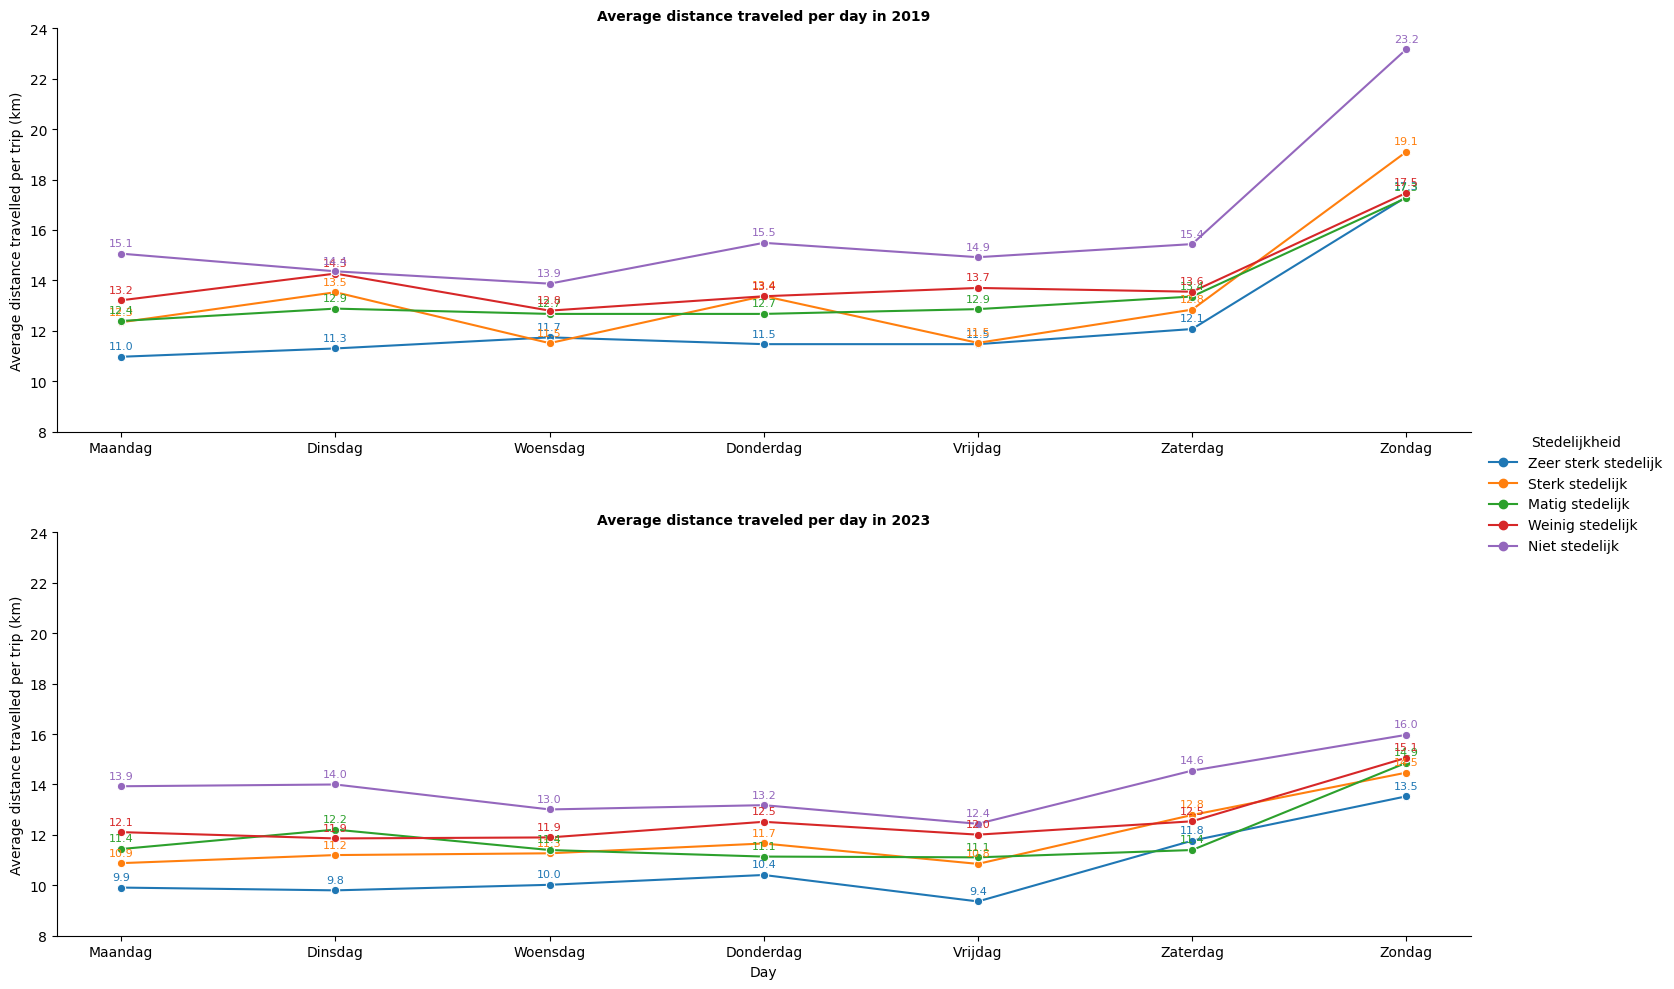

In [51]:
"""Making the graph for level of urbanity using seaborn"""
g = sns.relplot(
    data=df_long,        #dataframe used
    x='Day',             #Data shown on the x-axis is the days
    y='Gemiddelde_Afstand_km',  #Data shown on the y-axis is the distance travelled
    kind='line',         #Showing a line in the plot
    row='Jaar',          #Make two rows in the plot: one for the year 2019, and one for the year 2023
    hue='Stedelijkheid', #Every amount of urbanity gets its own colour in both graphs
    marker='o',          #Each datapoint is shown by a dot
    aspect=3.0,          #Makes the graph broader and thus better readable
    height=5,            #Determines the height of each graph
)

"""Adding lables for the axes and title"""
g.set_ylabels('Average distance travelled per trip (km)') #y axis label
g.set(ylim=(8, 24)) #setting a minimum and maximum for the y axis 
g.set_xlabels('Day') #x axis label
g.fig.subplots_adjust(hspace=0.25)  #add some more space between the two subplots 
g.set_titles("Average distance traveled per day in {row_name}",fontweight='bold') #title per subplot
for ax in g.axes.flat: #loop through both subplots
    ax.tick_params(axis='x', labeltop=False, labelbottom=True) #adding x-lables on both subplots

"""Adding data labels"""
for ax in g.axes.flat: #loop through both subplots
    for line in ax.lines: #loop through al lines in subplot
        x_data = line.get_xdata() #get the x data
        y_data = line.get_ydata() #get the y data

        for x, y in zip(x_data, y_data): #looping through x and y data
            ax.text(x, y + 0.3, f"{y:.1f}",  # 0.3 = placed above the data point
                    color=line.get_color(),
                    fontsize=8,
                    ha='center')
plt.show()

In [52]:
"""Filtering the data to make the graph for the entire Netherlands"""
df_long_total = df_long.copy()
df_long['Day'] = df_long['Day'].astype(str).str.strip() #remove all white spaces from the strings in column 'Day'
df_long_total = df_long_total[df_long_total['Day'].str.strip() != 'Totaal'] #only show columns with total travel distance, and not the distance per day
df_long_total = df_long_total[df_long_total['Stedelijkheid'].str.strip() == 'Nederland']
day_order = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag',] #making a list which shows the days in logical order
df_long_total['Day'] = pd.Categorical(df_long_total['Day'], categories=day_order, ordered=True) #sorting the days according to the logical order

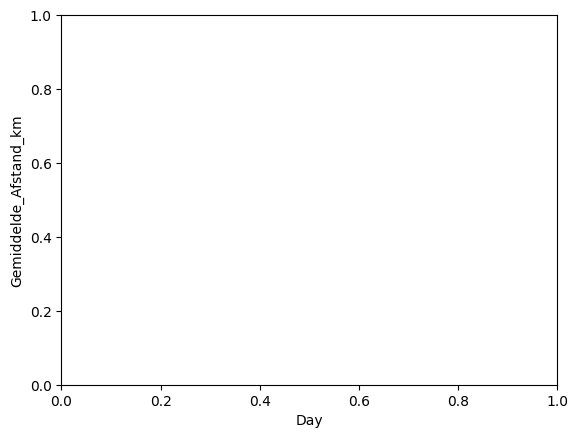

In [53]:
'''Making graph for Netherlands'''
ax = sns.lineplot(
    data=df_long_total,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Jaar',
    marker='o',
    dashes=False
)

## Pip ##

## Wendy ##

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Dataset1.csv',\
    delimiter=';',\
    encoding='utf-8-sig',
    skiprows=4) #skip the first 4 rows because they don't contain any needed data
df_copy = df.copy() #make a copy of the original dataframe
new_header = pd.MultiIndex.from_arrays(df.iloc[0:3].values) #make row with index 0,1 en 2 part of the column index. These rows don't contain any data and they should be part of the column index
df_copy.columns = new_header #make these rows part of the new column indexes
df1 = df_copy.iloc[3:] 

#Only select data for different types of leisure travel motives in 2019 and 2023
df1 = df1[
      ((df['Onderwerp'] == 'Winkelen, boodschappen doen') | (df['Onderwerp'] == 'Visite, logeren') |
      (df['Onderwerp'] == 'Uitgaan, sport, hobby') | (df['Onderwerp'] == 'Toeren, wandelen') |
      (df['Onderwerp'] == 'Totaal'))
  ]
df1

C:\Users\fleur\AppData\Local\Temp\ipykernel_27116\2958479966.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df1[


NaN               Regiokenmerken  \
                          NaN                     Perioden   
       Verplaatsingskenmerken                 Reismotieven   
3                     Totaal                        Totaal   
6                     Totaal   Winkelen, boodschappen doen   
7                     Totaal               Visite, logeren   
8                     Totaal         Uitgaan, sport, hobby   
9                     Totaal              Toeren, wandelen   
10     Verplaatsing op zondag                       Totaal   
13     Verplaatsing op zondag  Winkelen, boodschappen doen   
14     Verplaatsing op zondag              Visite, logeren   
15     Verplaatsing op zondag        Uitgaan, sport, hobby   
16     Verplaatsing op zondag             Toeren, wandelen   
17    Verplaatsing op maandag                       Totaal   
20    Verplaatsing op maandag  Winkelen, boodschappen doen   
21    Verplaatsing op maandag              Visite, logeren   
22    Verplaatsing op maandag        Uitgaan, sport, hobby   
23    Verplaatsing op maandag             Toeren, wandelen   
24    Verplaatsing op dinsdag                       Totaal   
27    Verplaatsing op dinsdag  Winkelen, boodschappen doen   
28    Verplaatsing op dinsdag              Visite, logeren   
29    Verplaatsing op dinsdag        Uitgaan, sport, hobby   
30    Verplaatsing op dinsdag             Toeren, wandelen   
31   Verplaatsing op woensdag                       Totaal   
34   Verplaatsing op woensdag  Winkelen, boodschappen doen   
35   Verplaatsing op woensdag              Visite, logeren   
36   Verplaatsing op woensdag        Uitgaan, sport, hobby   
37   Verplaatsing op woensdag             Toeren, wandelen   
38  Verplaatsing op donderdag                       Totaal   
41  Verplaatsing op donderdag  Winkelen, boodschappen doen   
42  Verplaatsing op donderdag              Visite, logeren   
43  Verplaatsing op donderdag        Uitgaan, sport, hobby   
44  Verplaatsing op donderdag             Toeren, wandelen   
45    Verplaatsing op vrijdag                       Totaal   
48    Verplaatsing op vrijdag  Winkelen, boodschappen doen   
49    Verplaatsing op vrijdag              Visite, logeren   
50    Verplaatsing op vrijdag        Uitgaan, sport, hobby   
51    Verplaatsing op vrijdag             Toeren, wandelen   
52   Verplaatsing op zaterdag                       Totaal   
55   Verplaatsing op zaterdag  Winkelen, boodschappen doen   
56   Verplaatsing op zaterdag              Visite, logeren   
57   Verplaatsing op zaterdag        Uitgaan, sport, hobby   
58   Verplaatsing op zaterdag             Toeren, wandelen   

             Nederland                     Zeer sterk stedelijk  \
                  2019                2023                 2019   
   reizigerskilometers reizigerskilometers  reizigerskilometers   
3                13,29               11,76                12,11   
6                 5,75                5,23                 4,31   
7                21,41               19,34                24,55   
8                13,09               12,63                11,52   
9                 9,52                7,12                 8,78   
10               18,33               14,52                17,31   
13                7,55                6,60                 4,70   
14               28,19               23,53                32,18   
15               17,67               15,68                17,35   
16               14,50                9,02                14,03   
17               12,41               11,21                10,97   
20                4,71                4,63                 3,22   
21               16,86               17,53                18,08   
22               10,89               10,77                 7,97   
23                6,68                6,01                 6,43   
24               13,12               11,37                11,30   
27                4,79                4,77                 3,62   
28               15

In [55]:
import plotly.express as px

In [56]:
#Figure1 General comparison of leisure travel motives for 2019 and 2023 
fig_leisure_total = px.line(df[df.Verplaatsingskenmerken == 'Totaal'], x = 'Perioden', 
    y = 'reizigerskilometers',color= 'Reismotieven',
    text ='Even kijken',
    labels={'Perioden':'Year','Reizigerskilometers':
            'Average traveled kilometers'})
fig_leisure_total.update_traces(textposition='top center')
fig_leisure_total.update_layout(title_text = 'Comparison of average travel numbers for leisure motives', 
                             yaxis=dict(tickmode = 'linear', tick0 = 0, dtick = 0.25))
fig_leisure_total.show()

AttributeError: 'DataFrame' object has no attribute 'Verplaatsingskenmerken'